# AI Demand Forecasting & Inventory Optimization

**Objective:** forecast product demand and translate the forecast into a practical inventory decision.

This notebook uses the included synthetic retail-demand data by default. It can be switched to the optional Walmart dataset after placing `train.csv` in `data/raw/`.

## 1. Imports and Project Setup

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.append(str(ROOT))

from src.data_prep import load_data
from src.forecast import add_features, time_split, seasonal_naive, evaluate, train_model
from src.inventory import inventory_policy


## 2. Load Data

In [2]:
df, source = load_data(use_real_data=False)
print("Data source:", source)
df.head()

Data source: demo


,Store,Product,Date,Demand
0,S01,P001,2022-01-07,184.57
1,S01,P001,2022-01-14,177.86
2,S01,P001,2022-01-21,215.20
3,S01,P001,2022-01-28,223.26
4,S01,P001,2022-02-04,178.72


The project uses a weekly demand series by store and product. The real-data adapter maps Walmart `Dept` to `Product` and `Weekly_Sales` to `Demand`.

## 3. Explore Demand

In [3]:
print(df.shape)
print(df.groupby(["Store", "Product"])["Demand"].agg(["mean", "std"]).round(2))


(936, 4)
                 mean    std
Store Product               
S01   P001     216.88  29.96
      P002     267.93  36.26
      P003     317.81  37.88
S02   P001     241.76  32.31
      P002     292.01  38.50
      P003     341.89  39.02


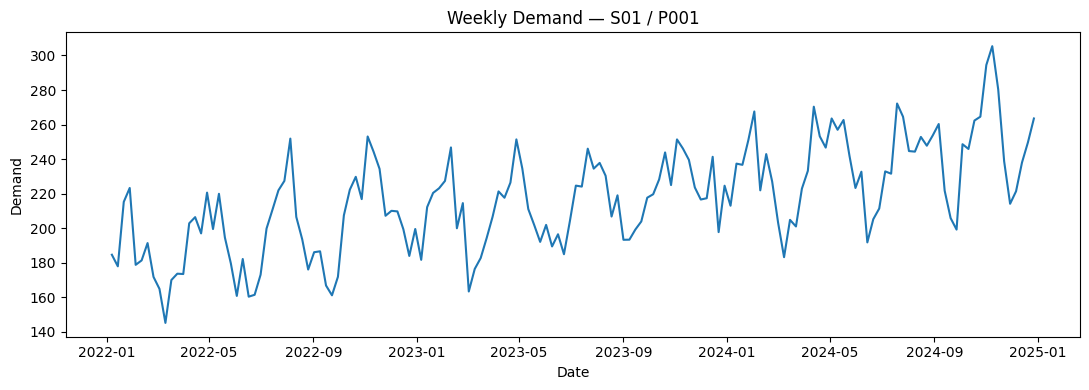

In [4]:
sample_key = ("S01", "P001")
series = df[(df.Store == sample_key[0]) & (df.Product == sample_key[1])]
plt.figure(figsize=(11, 4))
plt.plot(series.Date, series.Demand)
plt.title("Weekly Demand — S01 / P001")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.tight_layout()
plt.show()

## 4. Time-Series Feature Engineering

In [5]:
featured = add_features(df)
featured.head()

,Store,Product,Date,Demand,lag_1,lag_2,lag_4,lag_8,lag_13,lag_26,roll_mean_4,roll_std_4,roll_mean_8,roll_std_8,roll_mean_13,roll_std_13,weekofyear,month,year,sin_year,cos_year,store_code,product_code
0,S01,P001,2022-07-08,199.73,173.00,161.37,182.09,219.87,202.78,184.57,169.1825,10.354462,178.92375,20.542196,189.036154,21.262098,27,7,2022,-0.120537,-0.992709,0,0
1,S01,P001,2022-07-15,210.69,199.73,173.00,160.27,194.53,206.35,177.86,173.5925,18.352098,176.40625,15.397008,188.801538,21.114116,28,7,2022,-0.239316,-0.970942,0,0
2,S01,P001,2022-07-22,221.88,210.69,199.73,161.37,179.56,196.93,215.20,186.1975,22.902619,178.42625,18.798697,189.135385,21.446403,29,7,2022,-0.354605,-0.935016,0,0
3,S01,P001,2022-07-29,227.35,221.88,210.69,173.00,160.70,220.55,223.26,201.3250,20.936896,183.71625,24.309925,191.054615,23.243184,30,7,2022,-0.464723,-0.885456,0,0
4,S01,P001,2022-08-05,251.85,227.35,221.88,199.73,182.09,199.47,178.72,214.9125,12.268867,192.04750,26.607426,191.577692,24.025625,31,8,2022,-0.568065,-0.822984,0,0


Features include historical lags, rolling demand statistics, calendar variables, and cyclical seasonality. Because all lag and rolling features use prior observations, the validation window does not use future demand values.

## 5. Time-Based Validation Split

In [6]:
train, valid = time_split(featured, valid_weeks=13)
print("Train end:", train.Date.max())
print("Validation start:", valid.Date.min())
print("Validation end:", valid.Date.max())

Train end: 2024-09-27 00:00:00
Validation start: 2024-10-04 00:00:00
Validation end: 2024-12-27 00:00:00


A time-based split is used instead of random sampling because future observations should not be allowed to influence the past.

## 6. Baseline — Seasonal Naive

In [7]:
raw_train = df[df.Date < valid.Date.min()].copy()
naive_pred = seasonal_naive(raw_train, valid)
naive_metrics = evaluate(valid.Demand.to_numpy(), naive_pred)
naive_metrics

{'MAE': 26.705897435897434,
 'RMSE': 33.69615195256361,
 'WAPE': 0.081663135742725}

## 7. Machine-Learning Forecast

In [8]:
model, feature_cols, ml_pred = train_model(train, valid)
ml_metrics = evaluate(valid.Demand.to_numpy(), ml_pred)
ml_metrics

{'MAE': 23.560129608854936,
 'RMSE': 28.685067094034157,
 'WAPE': 0.0720437898401395}

## 8. Compare Models

In [9]:
metrics = pd.DataFrame([
    {"Model": "Seasonal Naive (13-week)", **naive_metrics},
    {"Model": "HistGradientBoostingRegressor", **ml_metrics},
])
metrics

,Model,MAE,RMSE,WAPE
0,Seasonal Naive (13-week),26.705897,33.696152,0.081663
1,HistGradientBoostingRegressor,23.560130,28.685067,0.072044


On the included synthetic demo, the ML model achieves lower error than the seasonal baseline. The generated CSV report contains the exact metrics used by the project README.

## 9. Forecast vs Actual

In [10]:
validation = valid[["Store", "Product", "Date", "Demand"]].copy()
validation["Forecast_Demand"] = ml_pred
validation["Absolute_Error"] = (validation.Demand - validation.Forecast_Demand).abs()
validation.head()

,Store,Product,Date,Demand,Forecast_Demand,Absolute_Error
117,S01,P001,2024-10-04,248.60,210.250447,38.349553
118,S01,P001,2024-10-11,245.85,232.308769,13.541231
119,S01,P001,2024-10-18,262.30,262.669355,0.369355
120,S01,P001,2024-10-25,264.55,272.409064,7.859064
121,S01,P001,2024-11-01,294.46,257.178783,37.281217


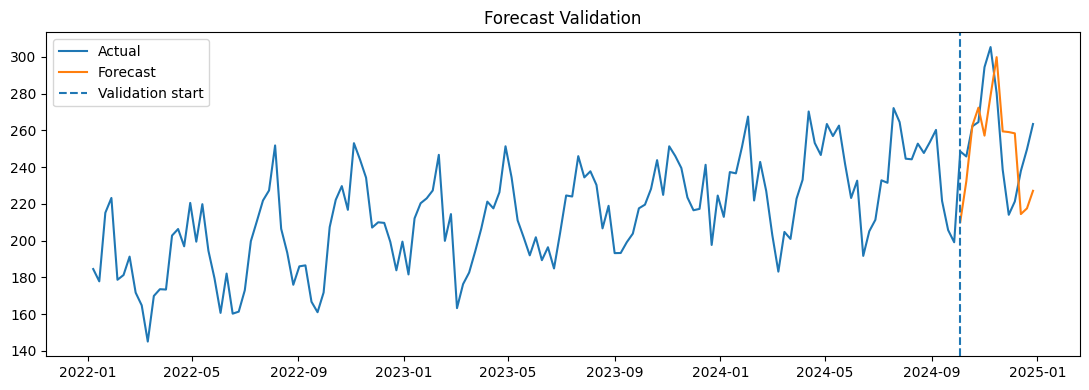

In [11]:
key = ("S01", "P001")
actual = df[(df.Store == key[0]) & (df.Product == key[1])]
pred = validation[(validation.Store == key[0]) & (validation.Product == key[1])]
plt.figure(figsize=(11, 4))
plt.plot(actual.Date, actual.Demand, label="Actual")
plt.plot(pred.Date, pred.Forecast_Demand, label="Forecast")
plt.axvline(pred.Date.min(), linestyle="--", label="Validation start")
plt.title("Forecast Validation")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Inventory Policy

In [12]:
last_date = validation.Date.max()
latest = validation[validation.Date == last_date].copy()
latest["on_hand_inventory"] = (latest.Forecast_Demand * 1.4).round(0)
recommendations = inventory_policy(
    df[df.Date < last_date],
    latest[["Store", "Product", "Date", "Forecast_Demand", "on_hand_inventory"]],
    lead_time_weeks=2,
    service_level=0.95,
)
recommendations[["Store", "Product", "Forecast_Demand", "safety_stock", "reorder_point", "recommended_order_qty", "risk_flag"]]

,Store,Product,Forecast_Demand,safety_stock,reorder_point,recommended_order_qty,risk_flag
0,S01,P001,227.148527,69.376382,523.673436,205.673436,REORDER
1,S01,P002,294.472635,84.402046,673.347317,261.347317,REORDER
2,S01,P003,360.706695,87.421479,808.834870,303.834870,REORDER
3,S02,P001,267.731594,75.367329,610.830517,235.830517,REORDER
4,S02,P002,336.551047,89.854371,762.956465,291.956465,REORDER
5,S02,P003,363.127485,90.703864,816.958833,308.958833,REORDER


The inventory layer translates the forecast into a simple replenishment recommendation using an explicit 2-week lead-time assumption and 95% service level. These assumptions should be replaced by company-specific planning parameters in a production setting.

## 11. Export Decision Tables

In [13]:
out_dir = ROOT / "reports"
out_dir.mkdir(exist_ok=True)
metrics.to_csv(out_dir / "metrics.csv", index=False)
validation.to_csv(out_dir / "forecast_validation.csv", index=False)
recommendations.to_csv(out_dir / "inventory_recommendations.csv", index=False)
print("Reports saved to:", out_dir)

Reports saved to: /mnt/data/ai-demand-forecasting-inventory-optimization/reports


## 12. Business Takeaway

The core idea is **forecast → inventory decision**. The model is useful because the forecast can be translated into a planning signal: how much demand is expected during lead time, how much safety stock is needed, and whether inventory should be replenished.